In [1]:
# --- Preload QWen and DAM models ---
import time
from hanoi_caption.image_describer import MODEL_NAME as QWEN_NAME
from hanoi_caption.region_describer import MODEL_NAME as DAM_NAME
from hanoi_caption.model_registry import registry
print("Preloading QWen and DAM models into memory...")
t0 = time.perf_counter()
# Load QWen
# registry.get(QWEN_NAME)
# print(f"QWen loaded. ({(time.perf_counter() - t0):.1f}s)")
# Load DAM
t1 = time.perf_counter()
registry.get(DAM_NAME)
print(f"DAM loaded. ({(time.perf_counter() - t1):.1f}s)")
print("\nModels successfully preloaded!")
print("Current loaded models:", registry.loaded())

Preloading QWen and DAM models into memory...


Fetching 20 files:   0%|          | 0/20 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

DAM loaded. (8.3s)

Models successfully preloaded!
Current loaded models: ['dam_3b']


In [2]:
import sys; sys.path.insert(0, "..")
from pathlib import Path
import json
import torch
from PIL import Image
import matplotlib.pyplot as plt

from hanoi_caption.kb_loader import load_kb
from hanoi_caption.kb_indexer import build_or_load_index
from hanoi_caption.pipeline import caption_phase1, caption_phase2
from hanoi_caption.model_registry import registry

nodes = load_kb("../data/kb.json")
kb_index = build_or_load_index(nodes)
print(f"KB ready: {len(nodes)} nodes")

KB ready: 181 nodes


In [ ]:
photos = [
    Path("../tests/fixtures/temple_of_literature_1.jpg"),
    Path("../tests/fixtures/temple_of_literature_2.jpg"),
    Path("../tests/fixtures/temple_of_literature_3.jpg"),
    Path("../tests/fixtures/hoangthanh.jpg"),
    Path("../tests/fixtures/gahanoi.jpg"),
    Path("../tests/fixtures/nhakhach.jpg"),
]
fig, axes = plt.subplots(1, 6, figsize=(15, 5))
for ax, p in zip(axes, photos):
    ax.imshow(Image.open(p)); ax.set_title(p.name); ax.axis("off")
plt.show()

In [ ]:
import time
from hanoi_caption.pipeline_retriever import caption_retriever

retriever_results = []
timing_data = []  # List of dicts: {photo, stage1, stage2, ..., total}

print("=" * 80)
print("RETRIEVER PIPELINE: BATCH PROCESSING ALL PHOTOS")
print("=" * 80)

def _name(node_id):
    return nodes[node_id].name_en if node_id in nodes else "?"

for photo_idx, p in enumerate(photos, start=1):
    img = Image.open(p).convert("RGB")
    
    t0 = time.perf_counter()
    r = caption_retriever(image=img, kb_nodes=nodes, kb_index=kb_index)
    elapsed = time.perf_counter() - t0
    
    retriever_results.append(r)
    
    # Build timing dict for this photo
    photo_timings = {"photo": p.name, "total": elapsed}
    stage_timings = r.debug.get("timings", {})
    photo_timings.update(stage_timings)
    timing_data.append(photo_timings)
    
    # Print per-photo results (same format as original cell)
    print(f"\n--- Retriever-only [{photo_idx}/6]: {p.name}  (caption generated in {elapsed:.1f}s) ---")
    print(r.caption or r.refusal)
    
    match = r.debug.get("match", {})
    chosen_id = match.get("node_id")
    top_k = match.get("top_k") or []
    
    if chosen_id and chosen_id in nodes:
        print(f"\nMatched: {_name(chosen_id)!r}  (id {chosen_id}, confidence {match.get('confidence', 0):.3f})")
    elif top_k:
        print(f"\nNo match (rerank refused). Cosine top-1 was {_name(top_k[0]['node_id'])!r} @ {top_k[0]['score']:.3f}")
    
    if top_k:
        print("\nCosine top-5:")
        for c in top_k[:5]:
            marker = "  <-- rerank pick" if c["node_id"] == chosen_id else ""
            print(f"  {c['score']:.3f}  {_name(c['node_id'])!r}{marker}")
    
    if stage_timings:
        print("\nPer-stage timings:")
        for name, secs in stage_timings.items():
            print(f"  {name:18s}  {secs:6.2f}s")
        print(f"  {'total':18s}  {sum(stage_timings.values()):6.2f}s")

print("\n" + "=" * 80)
print(f"Completed batch processing of {len(retriever_results)} photos")
print("=" * 80)

In [ ]:
import matplotlib.pyplot as plt

# Extract timing stage names (same across all photos, from first result's keys)
if timing_data:
    # Get all unique stage names (exclude 'photo' and 'total')
    stage_names = sorted(set(key for td in timing_data for key in td.keys() if key not in ['photo', 'total']))
    
    # Build table data
    table_rows = []
    for td in timing_data:
        row = [td['photo']]
        for stage in stage_names:
            row.append(f"{td.get(stage, 0):.2f}s")
        row.append(f"{td.get('total', 0):.1f}s")
        table_rows.append(row)
    
    # Column headers
    columns = ['Photo'] + [s.replace('_', '\n') for s in stage_names] + ['Total']
    
    # Create figure and table
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.axis('tight')
    ax.axis('off')
    
    table = ax.table(
        cellText=table_rows,
        colLabels=columns,
        cellLoc='center',
        loc='center',
        colWidths=[0.25] + [0.1] * len(stage_names) + [0.1]
    )
    
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)
    
    # Style header row
    for i in range(len(columns)):
        table[(0, i)].set_facecolor('#4CAF50')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    # Style data rows with alternating colors
    for i in range(1, len(table_rows) + 1):
        for j in range(len(columns)):
            if j == len(columns) - 1:  # total column
                table[(i, j)].set_facecolor('#fffacd')
                table[(i, j)].set_text_props(weight='bold')
            else:
                bg_color = '#f0f0f0' if i % 2 == 0 else '#ffffff'
                table[(i, j)].set_facecolor(bg_color)
    
    plt.title('Retriever Pipeline: Per-Stage Timing Breakdown (All 6 Photos)', 
              fontsize=12, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\nTiming Summary Statistics:")
    print("-" * 60)
    for stage in ['total'] + stage_names:
        values = [td[stage] for td in timing_data if stage in td]
        if values:
            print(f"  {stage:20s}  min: {min(values):6.3f}s  max: {max(values):6.3f}s  avg: {sum(values)/len(values):6.3f}s")
else:
    print("No timing data collected. Make sure the batch processing cell ran successfully.")

In [ ]:
import sys
import os
import time
import json
import faiss
from PIL import Image

sys.path.insert(0, "..")
sys.path.append("../scripts/data_collection")
from feature_extractor import FeatureExtractor
from hanoi_caption.kb_loader import index_by_kb_id
from hanoi_caption.pipeline_retriever import _dam_caption_with_landmark

print("=" * 80)
print("VISUAL RAG PIPELINE (DINOv3 + DAM): BATCH PROCESSING")
print("=" * 80)

# Load FAISS index and map
index_path = "../data/cache/dino_faiss.index"
map_path = "../data/cache/id_map.json"
dino_index = faiss.read_index(index_path)
with open(map_path, 'r') as f:
    id_map = {int(k): v for k, v in json.load(f).items()}

extractor = FeatureExtractor() # using dinov3-vits16 behind the scenes

# Folders under data/kb_images/ are named by KBNode.kb_id (human-readable slug),
# not the opaque KBNode.id used to key `nodes`. Build a slug -> node lookup.
nodes_by_kb_id = index_by_kb_id(nodes)

def get_kb_id_from_path(path):
    # Extract kb_id from path like '.../data/kb_images/<kb_id>/image.jpg'
    return os.path.basename(os.path.dirname(path))

dino_timing_data = []

for photo_idx, p in enumerate(photos, start=1):
    img = Image.open(p).convert("RGB")
    t0 = time.perf_counter()
    
    # 1. Retrieval using DINOv3
    t_ret_start = time.perf_counter()
    query_feat = extractor.extract_features(img).astype('float32')
    scores, indices = dino_index.search(query_feat, k=5)
    
    # Simple top-1 voting
    top_path = id_map.get(indices[0][0])
    matched_kb_id = get_kb_id_from_path(top_path)
    matched_node = nodes_by_kb_id.get(matched_kb_id)
    t_ret = time.perf_counter() - t_ret_start
    
    # 2. Generation using DAM-3B
    t_gen_start = time.perf_counter()
    if matched_node is not None:
        caption = _dam_caption_with_landmark(img, matched_node)
    else:
        caption = "Refusal: Not a recognized Hanoi landmark."
    t_gen = time.perf_counter() - t_gen_start
    
    elapsed = time.perf_counter() - t0
    
    dino_timing_data.append({
        "photo": p.name,
        "dino_retrieval": t_ret,
        "dam_caption": t_gen,
        "total": elapsed
    })
    
    display_name = matched_node.name_en if matched_node is not None else matched_kb_id
    print(f"\n--- Visual RAG [{photo_idx}/6]: {p.name}  (total: {elapsed:.2f}s) ---")
    print(f"Matched: {display_name!r} (retrieval in {t_ret:.3f}s)")
    print(caption)

print("\n" + "=" * 80)
print(f"Completed DINOv3 Visual RAG processing of {len(photos)} photos")
print("=" * 80)


In [ ]:
import matplotlib.pyplot as plt

# Table for DINOv3 Visual RAG timings
if dino_timing_data:
    stage_names = ['dino_retrieval', 'dam_caption']
    table_rows = []
    for td in dino_timing_data:
        row = [td['photo']]
        for stage in stage_names:
            row.append(f"{td.get(stage, 0):.2f}s")
        row.append(f"{td.get('total', 0):.1f}s")
        table_rows.append(row)
    
    columns = ['Photo', 'DINO\nRetrieval', 'DAM\nCaption', 'Total']
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.axis('tight')
    ax.axis('off')
    
    table = ax.table(
        cellText=table_rows,
        colLabels=columns,
        cellLoc='center',
        loc='center',
        colWidths=[0.3, 0.2, 0.2, 0.2]
    )
    
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)
    
    # Style header row
    for i in range(len(columns)):
        table[(0, i)].set_facecolor('#2196F3')  # Blue for new architecture
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    # Style data rows
    for i in range(1, len(table_rows) + 1):
        for j in range(len(columns)):
            if j == len(columns) - 1:
                table[(i, j)].set_facecolor('#e3f2fd')
                table[(i, j)].set_text_props(weight='bold')
            else:
                bg_color = '#f0f0f0' if i % 2 == 0 else '#ffffff'
                table[(i, j)].set_facecolor(bg_color)
    
    plt.title('DINOv3 Visual RAG: Per-Stage Timing Breakdown', 
              fontsize=12, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\nTiming Summary Statistics (DINOv3 Visual RAG):\n" + "-" * 60)
    for stage in ['total'] + stage_names:
        values = [td[stage] for td in dino_timing_data if stage in td]
        if values:
            print(f"  {stage:20s}  min: {min(values):6.3f}s  max: {max(values):6.3f}s  avg: {sum(values)/len(values):6.3f}s")


In [3]:
# --- Video pipeline demo: run caption_video on a real clip ---
import time
from pathlib import Path

from hanoi_caption.video_pipeline import caption_video

VIDEO_PATH = Path("../tests/fixtures/video/A39_203_HTTLCongDoanMonTrai_M_T02.MOV")

if not VIDEO_PATH.exists():
    print(f"Drop a video at: {VIDEO_PATH.resolve()}")
    print("(A 10-60s walking-tour clip showing 1-3 Hanoi landmarks works well.)")
    segments = []
else:
    print(f"Processing {VIDEO_PATH.name} ...")
    t0 = time.perf_counter()
    segments = caption_video(
        video_path=VIDEO_PATH,
        kb_nodes=nodes,
        dino_index_path="../data/cache/dino_faiss.index",
        id_map_path="../data/cache/id_map.json",
        sample_fps=1.0,
        smooth_window=3,
        min_segment_seconds=2.0,
        dam_frame_budget=(4, 8),
    )
    elapsed = time.perf_counter() - t0
    print(f"Done in {elapsed:.1f}s -> {len(segments)} segment(s)")


Processing A39_203_HTTLCongDoanMonTrai_M_T02.MOV ...


Using device: cuda


Done in 56.4s -> 4 segment(s)


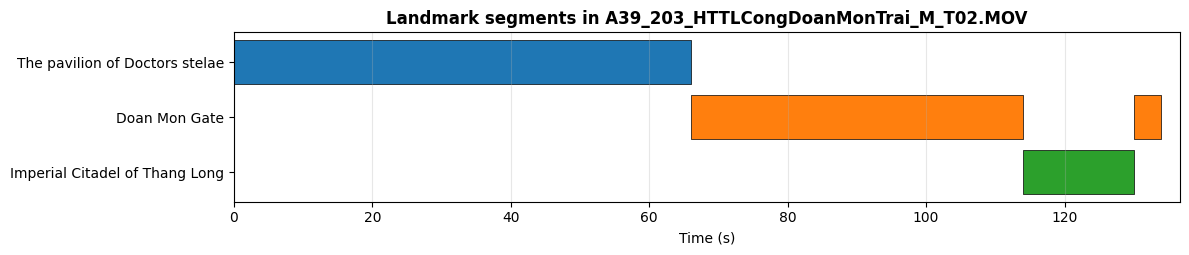

Segment 1: 0.0s - 66.0s  (66.0s)
Landmark : The pavilion of Doctors stelae  (confidence 0.448)
Frames   : 8/66  DAM: 8.1s
--------------------------------------------------------------------------------
The pavilion of Doctors stelae is a historical and cultural landmark located in Vietnam. It was built in 1484 by the enlightened monarch Lê Thánh Tông to honor highly accomplished scholars in the kỳ thi đình. The pavilion is a stone chronicle that resembles a stone inscription, embracing and inscribing the essence of Vietnamese intellect. The steles are weathered by time and are adorned with the image of a divine turtle carrying on its back stone slabs densely carved with Hán characters. The pavilion is surrounded by low tiled-roof structures and lush ancient trees, reflecting its image into the calm Thiên Quang well.
Segment 2: 66.0s - 114.0s  (48.0s)
Landmark : Doan Mon Gate  (confidence 0.601)
Frames   : 8/48  DAM: 6.6s
----------------------------------------------------------------

In [4]:
# --- Render segments: timeline plot + caption list ---
import matplotlib.pyplot as plt

if not segments:
    print("No segments to render. Run the previous cell first.")
else:
    # Unique landmarks in order of appearance.
    seen = {}
    for s in segments:
        if s.kb_id not in seen:
            seen[s.kb_id] = s.name_en
    unique_kb_ids = list(seen.keys())
    cmap = plt.get_cmap("tab10")
    color_by_kb_id = {kb_id: cmap(i % 10) for i, kb_id in enumerate(unique_kb_ids)}

    # Timeline: one row per landmark, broken_barh shows segment spans.
    fig, ax = plt.subplots(figsize=(12, 1.0 + 0.55 * len(unique_kb_ids)))
    for i, kb_id in enumerate(unique_kb_ids):
        spans = [(s.start_s, s.end_s - s.start_s) for s in segments if s.kb_id == kb_id]
        ax.broken_barh(spans, (i - 0.4, 0.8),
                       facecolors=color_by_kb_id[kb_id], edgecolor="black", linewidth=0.5)

    ax.set_yticks(range(len(unique_kb_ids)))
    ax.set_yticklabels([seen[k] for k in unique_kb_ids])
    ax.invert_yaxis()  # first landmark on top
    ax.set_xlabel("Time (s)")
    ax.set_xlim(0, max(s.end_s for s in segments) * 1.02)
    ax.set_title(f"Landmark segments in {VIDEO_PATH.name}", fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Captions list.
    for i, s in enumerate(segments, 1):
        print("=" * 80)
        print(f"Segment {i}: {s.start_s:.1f}s - {s.end_s:.1f}s  ({s.end_s - s.start_s:.1f}s)")
        print(f"Landmark : {s.name_en}  (confidence {s.confidence:.3f})")
        print(f"Frames   : {s.debug.get('frames_sampled', '?')}/{s.debug.get('frames_total', '?')}  "
              f"DAM: {s.debug.get('timings', {}).get('dam_caption', 0):.1f}s")
        print("-" * 80)
        print(s.caption)
    print("=" * 80)
